 1. CatBoostClassifier:
 #################################
Boosting method: Gradient Boosting on Decision Trees
Special feature: Automatically handles categorical features without manual encoding.
When to use: When you have a mix of numerical and categorical features, and want ease of use + state-of-the-art performance.
✅ Pros:
Great accuracy
No need for one-hot encoding
Resistant to overfitting
Easy to use on real-world datasets
🚫 Cons:
Slightly slower than LightGBM
Can be complex under the hood


🌲 2. RandomForestClassifier (by scikit-learn)
#################################
Method: Bagging (ensemble of decision trees trained independently)
When to use: When you want a fast, simple, and stable model with solid performance.

✅ Pros:
Fast training
Easy to interpret (with feature importance)
Good default performance

🚫 Cons:
Doesn't handle categorical variables directly
Might underperform compared to boosting models
Less flexible for complex tasks

⚡ 3. LGBMClassifier (LightGBM by Microsoft)
#################################
Boosting method: Gradient Boosting using leaf-wise tree growth (very efficient)
When to use: When you have large datasets and need fast training.

✅ Pros:
Extremely fast
High accuracy
Works well on large datasets
Handles categorical features (but requires converting them to category dtype)

🚫 Cons:
More sensitive to overfitting
Needs careful tuning
Not as intuitive to interpret

🚀 4. XGBClassifier (XGBoost)
#################################
Boosting method: Gradient Boosting using level-wise growth
When to use: When you want a battle-tested, high-performance boosting model

✅ Pros:
Highly accurate
Robust and mature
Supports regularization to prevent overfitting
Works well with missing values

🚫 Cons:
Requires manual encoding of categorical features
Training can be slower than LightGBM



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the necessary libraries

In [2]:
data =pd.read_csv('F:\\STEMETA_Intership_Projects\\Spam_email_Detection\\emails.csv')  # Load the dataset
data.head()  # Display the first few rows of the dataset

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [3]:
data.drop(columns=['Email No.'],inplace=True)

# drop the unnecessary column 

In [4]:
data.isnull().sum().sum()  # Check for missing values in the dataset

# check for missing values  

0

In [5]:
data.duplicated().sum()  # Check for duplicate rows in the dataset

541

In [6]:
data.drop_duplicates(inplace=True)  # Remove duplicate rows

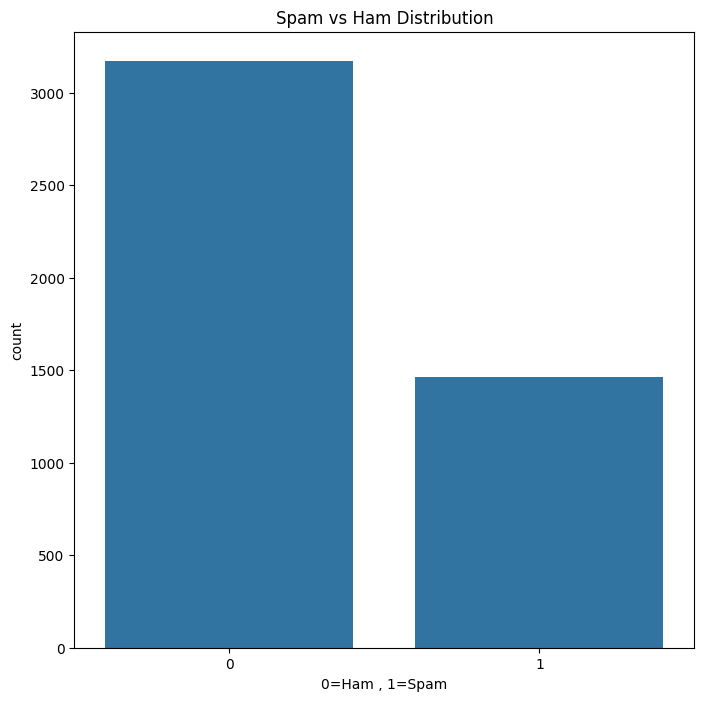

In [7]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Prediction', data=data)
plt.title("Spam vs Ham Distribution")
plt.xlabel("0=Ham , 1=Spam")
plt.show()

# explore the data with countplot

In [8]:
import pandas as pd
from sklearn.utils import resample
from collections import Counter


In [9]:
print(Counter(data['Prediction']))
# Display the count of each class in the dataset

Counter({0: 3170, 1: 1461})


In [10]:
# Split majority and minority classes
ham = data[data['Prediction'] == 0]
spam = data[data['Prediction'] == 1]
# Resample the minority class (spam) to match the majority class (ham)

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

In [12]:
ham_downsampled = resample(ham,
                           replace=False,  # Without replacement
                           n_samples=len(spam),  # Match number of spam
                           random_state=42)

# Combine minority class (spam) with downsampled majority (ham)
data_balanced = pd.concat([ham_downsampled, spam])


In [13]:
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
# Shuffle the dataset after balancing

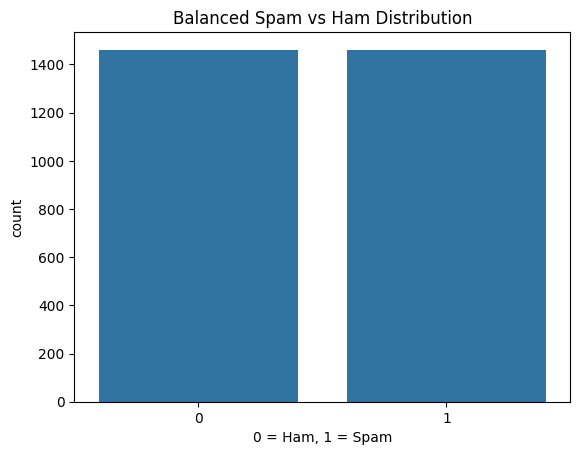

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Prediction', data=data_balanced)
plt.title("Balanced Spam vs Ham Distribution")
plt.xlabel("0 = Ham, 1 = Spam")
plt.show()


In [15]:
x = data.drop(columns='Prediction',axis=1)
y = data['Prediction']

In [16]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# split the data

In [18]:
# display the distribution of classes in y
print(y.value_counts())

Prediction
0    3170
1    1461
Name: count, dtype: int64


In [20]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

model_catboost = CatBoostClassifier(verbose=0)
model_catboost.fit(x_train, y_train)
y_pred = model_catboost.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 97.99%


In [21]:
print(f"Train Score : {model_catboost.score(x_train, y_train) * 100:.2f}%")
print(f"Test Score  : {model_catboost.score(x_test, y_test) * 100:.2f}%")

# display training and test accuracy 

Train Score : 100.00%
Test Score  : 97.99%


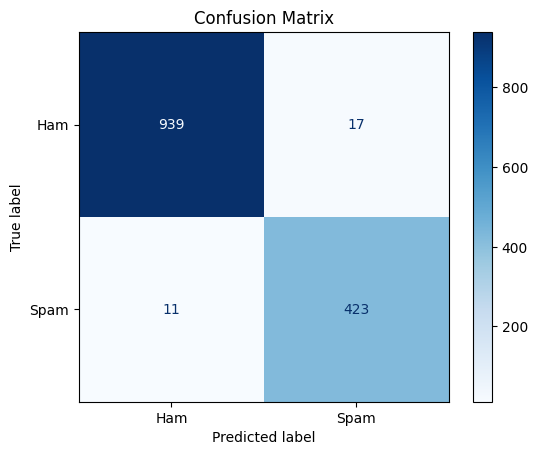

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Ham", "Spam"]) 
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

✅ 1. True Negative (TN) = 939
Model predicted Ham, and actual label is also Ham.
Correctly identified as Ham.
❌ 2. False Positive (FP) = 17
Model predicted Spam, but actual label was Ham.
Wrongly flagged a normal message as spam.
❌ 3. False Negative (FN) = 11
Model predicted Ham, but actual label was Spam.
Missed detecting spam.
✅ 4. True Positive (TP) = 423
Model predicted Spam, and the actual label was also Spam.
Correctly caught a spam message.

Quick Summary of the Formulas
TN: Actual = 0, Predicted = 0
FP: Actual = 0, Predicted = 1
FN: Actual = 1, Predicted = 0
TP: Actual = 1, Predicted = 1

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.9798561151079137
Precision: 0.9613636363636363
Recall: 0.9746543778801844
F1 Score: 0.9679633867276888


 The Accuracy : 97.99%


Text(0.5, 1.0, 'Model Accuracy on Train and Test Sets')

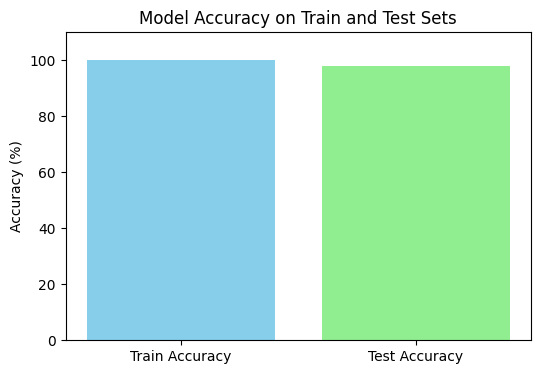

In [25]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f""" The Accuracy : {accuracy * 100:.2f}%""")

# print the accuracy of the model
train_score = accuracy_score(y_train, model_catboost.predict(x_train)) * 100
test_score = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(6, 4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_score, test_score], color=['skyblue', 'lightgreen'])
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy on Train and Test Sets')

In [50]:
# Save model to a .pkl file
import pickle
with open("catboost_model.pkl", "wb") as f:
    pickle.dump(model_catboost, f)